
# Spread Locator – Statistical Distribution Analysis
This notebook performs statistical analysis on e-commerce transaction data.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## Load Dataset

In [2]:

# Replace with your dataset file
df = pd.read_excel("spreadsheet.xlsx")

df.head()


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


## Basic Dataset Info

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    object        
 1   customer_id         220 non-null    object        
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[ns]
 4   transaction_count   220 non-null    int64         
 5   region              220 non-null    object        
 6   transaction_status  220 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.2+ KB


,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


## Binomial Distribution (Transaction Success/Failure)

In [4]:

success_rate = (df['transaction_status'] == 'Success').mean()
n = len(df)

print("Estimated Success Probability:", success_rate)


Estimated Success Probability: 0.44545454545454544


## Poisson Distribution (Transactions per Day)

In [5]:

transactions_per_day = df.groupby('transaction_date').size()

lambda_rate = transactions_per_day.mean()
print("Average transactions per day:", lambda_rate)


Average transactions per day: 7.096774193548387


## Log-Normal Distribution Fit for Transaction Amounts

In [6]:

amounts = df['transaction_amount']

shape, loc, scale = stats.lognorm.fit(amounts)

print("LogNormal parameters:", shape, loc, scale)


LogNormal parameters: 0.5416831487801056 333.7722748609052 2604.740667049811


## Q-Q Plot for Normality

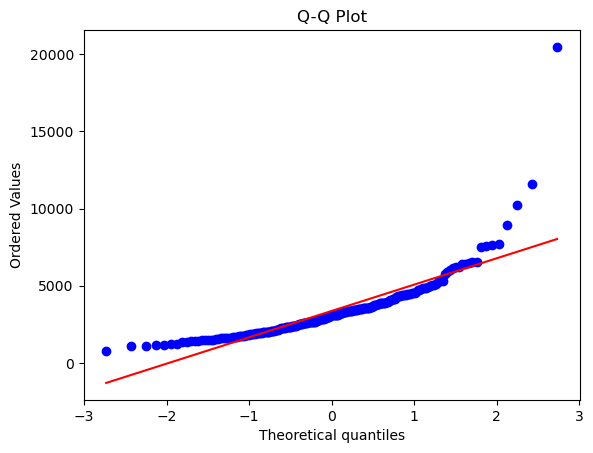

In [7]:

stats.probplot(amounts, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


## Box-Cox Transformation

In [8]:

amounts_positive = amounts + 1
transformed, lambda_val = stats.boxcox(amounts_positive)

print("Lambda:", lambda_val)


Lambda: -0.18123614601505497


## Z-Scores

In [9]:

z_scores = stats.zscore(amounts)

df['z_score'] = z_scores
df[['transaction_amount','z_score']].head()


,transaction_amount,z_score
0,3821.34,0.230240
1,2781.84,-0.294446
2,4120.97,0.381477
3,6383.78,1.523626
4,2651.61,-0.360179


## PDF and CDF Visualization

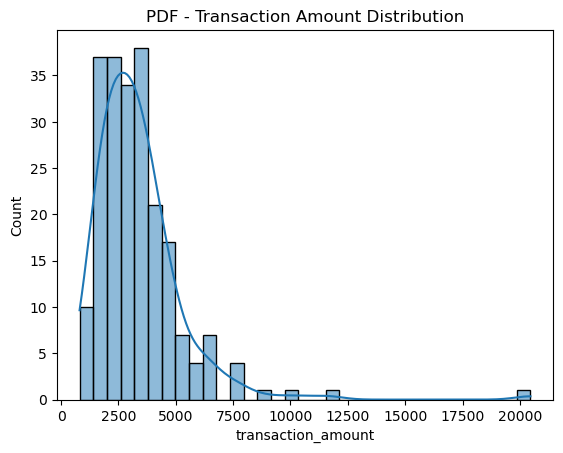

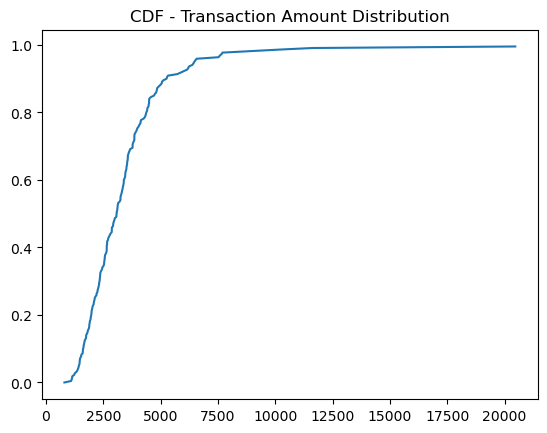

In [10]:

sns.histplot(amounts, kde=True)
plt.title("PDF - Transaction Amount Distribution")
plt.show()

sorted_data = np.sort(amounts)
cdf = np.arange(len(sorted_data)) / float(len(sorted_data))

plt.plot(sorted_data, cdf)
plt.title("CDF - Transaction Amount Distribution")
plt.show()
